## Example 6.3.2

$$
  \begin{split}
    \frac{d y}{d t} &= y(1-\alpha y) - \frac{yz}{1+\beta y} \\
    \frac{d z}{d t} &= -z + \frac{yz}{1+\beta y}
  \end{split}
  $$

In [40]:
function predprey(u, p, t)
    α, β = p      # rename parameters for convenience
    y, z = u      # rename solution components
    s = (y * z) / (1 + β * y)     # appears in both equations
    return [y * (1 - α * y) - s, -z + s]
end;

In [41]:
using OrdinaryDiffEq
u₀ = [1, 0.01]
tspan = (0.0, 60.0)
α, β = 0.1, 0.25
ivp = ODEProblem(predprey, u₀, tspan, [α, β])

ODEProblem with uType Vector{Float64} and tType Float64. In-place: false
Non-trivial mass matrix: false
timespan: (0.0, 60.0)
u0: 2-element Vector{Float64}:
 1.0
 0.01

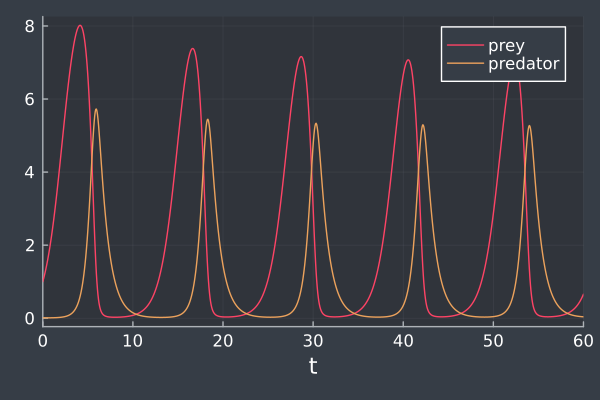

In [42]:
using Plots, LaTeXStrings
theme(:dark);  default(thickness_scaling=1.4)
sol = solve(ivp);
plot(sol, label=["prey" "predator"])

In [43]:
t, u = sol.t, sol.u    # extract times and solution values
size(u)

(100,)

In [44]:
u[20]

2-element Vector{Float64}:
 0.027739191695661334
 0.699418322938034

In [45]:
using FNCFunctions
t, u = FNC.euler(ivp, 1200);
size(u)

(1201,)

In [46]:
u = [u[j] for u in u, j in 1:2]
size(u)

(1201, 2)

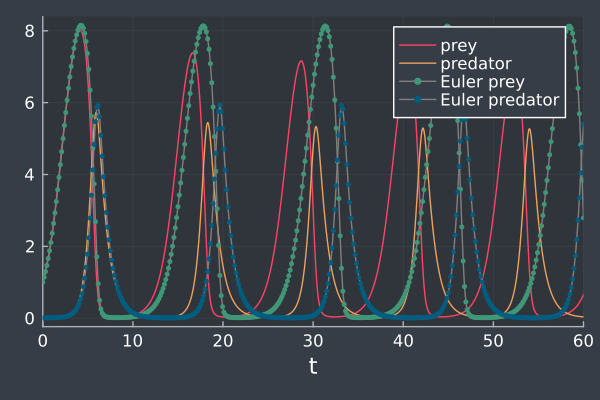

In [47]:
plot!(t[1:3:end], u[1:3:end, :];
    l=(1, :gray),  m=2, msw=0, label=["Euler prey" "Euler predator"])

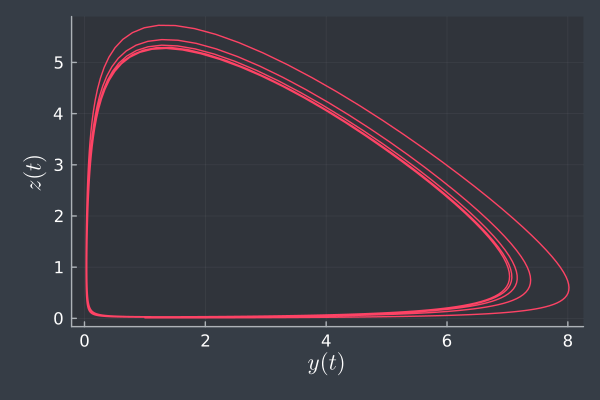

In [48]:
plot(sol, idxs=(1, 2), legend=false, xlabel=L"y(t)",  ylabel=L"z(t)")

In [49]:
prey, predator = [], []
anim = @animate for t in range(0, 60, 801)
    y, z = sol(t)
    plot(prey, predator; xlabel=L"y(t)", ylabel=L"z(t)", legend=false)
    push!(prey, y)
    push!(predator, z)
    scatter!([y], [z], m=(5, :red))
    xlims!(0, 9)
    ylims!(0, 6)
end
mp4(anim, "predator-prey.mp4")

[ Info: Saved animation to /Users/driscoll/Documents/GitHub/fnc/demos/predator-prey.mp4


Plots.AnimatedGif("/Users/driscoll/Documents/GitHub/fnc/demos/predator-prey.mp4")

## Example 6.3.5

$$
\begin{split}
  \theta_1''(t) +\gamma \theta_1' + \frac{g}{L} \sin \theta_1 +
  k(\theta_1-\theta_2) &= 0\\
  \theta_2''(t) +\gamma \theta_2' + \frac{g}{L} \sin \theta_2 +
  k(\theta_2-\theta_1) &= 0
\end{split}
$$

$$
\begin{split}
  u_1' &= u_3 \\
  u_2' &= u_4 \\
  u_3' &= -\gamma u_3 - \frac{g}{L}\sin u_1 + k(u_2-u_1) \\
  u_4' &= -\gamma u_4 - \frac{g}{L}\sin u_2 + k(u_1-u_2)
\end{split}
$$

In [50]:
function couple(u, p, t)
    γ, L, k = p
    g = 9.8
    udot = similar(u)
    udot[1:2] .= u[3:4]
    udot[3] = -γ * u[3] - (g / L) * sin(u[1]) + k * (u[2] - u[1])
    udot[4] = -γ * u[4] - (g / L) * sin(u[2]) + k * (u[1] - u[2])
    return udot
end;

In [51]:
u₀ = [1.25, -0.3, 0, 0]
tspan = (0.0, 50.0);
γ, L, k = 0, 0.5, 0

using OrdinaryDiffEq
ivp = ODEProblem(couple, u₀, tspan, [γ, L, k])
sol = solve(ivp);

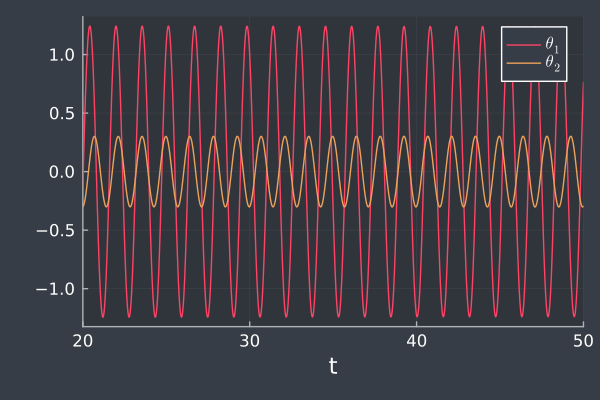

In [52]:
using Plots, LaTeXStrings
theme(:dark);  default(thickness_scaling=1.4)
plot(sol, idxs=[1, 2], label=[L"\theta_1" L"\theta_2"], xlims=[20, 50])

In [53]:
using Printf
anim = @animate for t in range(0, 24, 251)
    θ₁, θ₂, _ = sol(t)
    plot([0, sin(θ₁)], [0, -cos(θ₁)], l=4;
        layout=(1, 2), aspect_ratio=1, grid=false,
        xaxis=((-1.1, 1.1), false), yaxis=((-1.1, 0.1), false), legend=false)
    plot!([0, sin(θ₂)], [0, -cos(θ₂)], l=4;
        subplot=2, aspect_ratio=1, grid=false,
        xaxis=((-1.1, 1.1), false), yaxis=((-1.1, 0.1), false), legend=false)
    scatter!([sin(θ₁)], [-cos(θ₁)], m=(5, :gray), msw=0, subplot=1)
    scatter!([sin(θ₂)], [-cos(θ₂)], m=(5, :gray), msw=0, subplot=2)
    annotate!(-0.95, 0.25, Plots.text(@sprintf("t = %.1f", t), :left, 11, :white); subplot=1)
end
mp4(anim, "pendulums-weak.mp4")

[ Info: Saved animation to /Users/driscoll/Documents/GitHub/fnc/demos/pendulums-weak.mp4


Plots.AnimatedGif("/Users/driscoll/Documents/GitHub/fnc/demos/pendulums-weak.mp4")

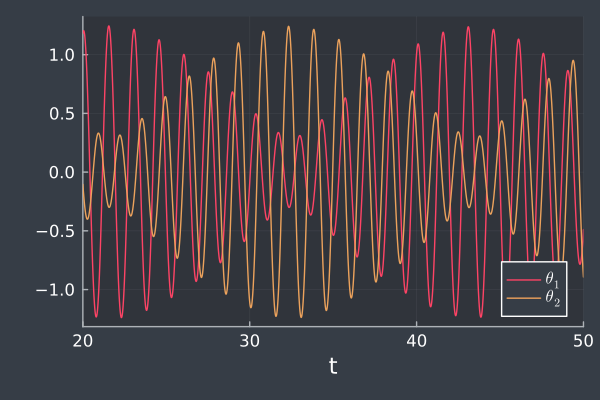

In [54]:
k = 1    # stronger coupling
ivp = ODEProblem(couple, u₀, tspan, [γ, L, k])
sol = solve(ivp)
plot(sol, idxs=[1, 2], label=[L"\theta_1" L"\theta_2"], xlims=[20, 50])

In [55]:
anim = @animate for t in range(0, 50, 601)
    θ₁, θ₂, _ = sol(t)
    plot([0, sin(θ₁)], [0, -cos(θ₁)], l=4;
        layout=(1, 2), aspect_ratio=1, grid=false,
        xaxis=((-1.1, 1.1), false), yaxis=((-1.1, 0.1), false), legend=false)
    plot!([0, sin(θ₂)], [0, -cos(θ₂)], l=4;
        subplot=2, aspect_ratio=1, grid=false,
        xaxis=((-1.1, 1.1), false), yaxis=((-1.1, 0.1), false), legend=false)
    scatter!([sin(θ₁)], [-cos(θ₁)], m=(5, :gray), msw=0, subplot=1)
    scatter!([sin(θ₂)], [-cos(θ₂)], m=(5, :gray), msw=0, subplot=2)
    annotate!(-0.95, 0.25, Plots.text(@sprintf("t = %.1f", t), :left, 11, :white); subplot=1)
end
mp4(anim, "pendulums-strong.mp4")

[ Info: Saved animation to /Users/driscoll/Documents/GitHub/fnc/demos/pendulums-strong.mp4


Plots.AnimatedGif("/Users/driscoll/Documents/GitHub/fnc/demos/pendulums-strong.mp4")